In [19]:
import pandas as pd
import numpy as np
import seaborn as sns

In [20]:
live = pd.read_csv("../data/samples/mega/live_metrics.csv")
verbose = pd.read_csv("../data/samples/mega/verbose_statements.csv")
initial = pd.read_csv("../data/samples/mega/initial_statement.csv")

In [21]:
live = live.drop(['Unnamed: 0', "_id", "Category", "Collect", ], axis=1)

In [22]:
live['Current Time'] = pd.to_datetime(live['Current Time'])
live['Current Time'] = pd.to_numeric(live['Current Time'])

In [23]:
response_time = verbose['total_duration'].tolist()
eval_rate = verbose['eval_rate'].tolist()
response_time = response_time[:-1]
reset_iters = live[live['Iteration'] == 1].index.tolist()
eval_rates = [np.float64(evals[:-9]) for evals in eval_rate]

In [24]:
live_copy = live.copy()
live_copy = live_copy.dropna()
corr_matrix = live_copy.corr()

In [25]:
live = live.drop(columns=['Memory Current Clock (MHz)'])
live_copy = live_copy.drop(columns=['Memory Current Clock (MHz)'])

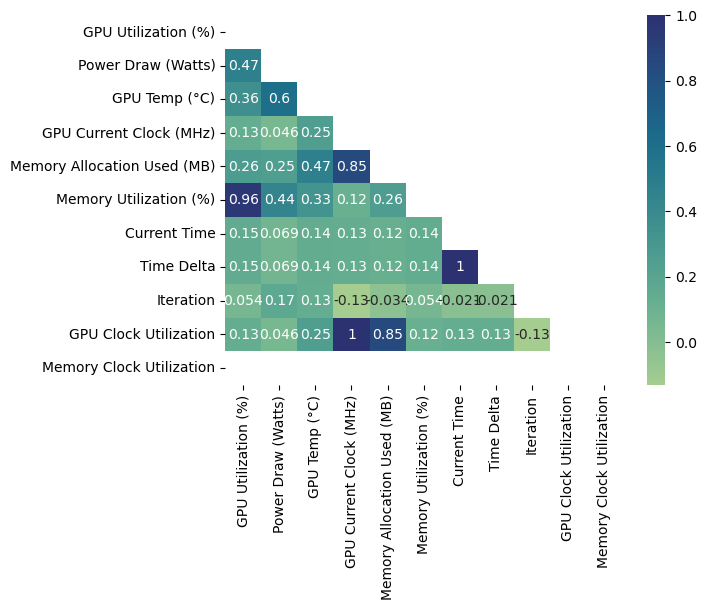

In [26]:
mask = np.triu(np.ones_like(live_copy.corr(), dtype=bool))
heatmap = sns.heatmap(live_copy.corr(), mask=mask, cmap='crest', annot=True)

In [27]:
# tri_up = corr_matrix.mask(mask)
# to_drop = [col for col in tri_up.columns if any(tri_up[col] > 0.9)]

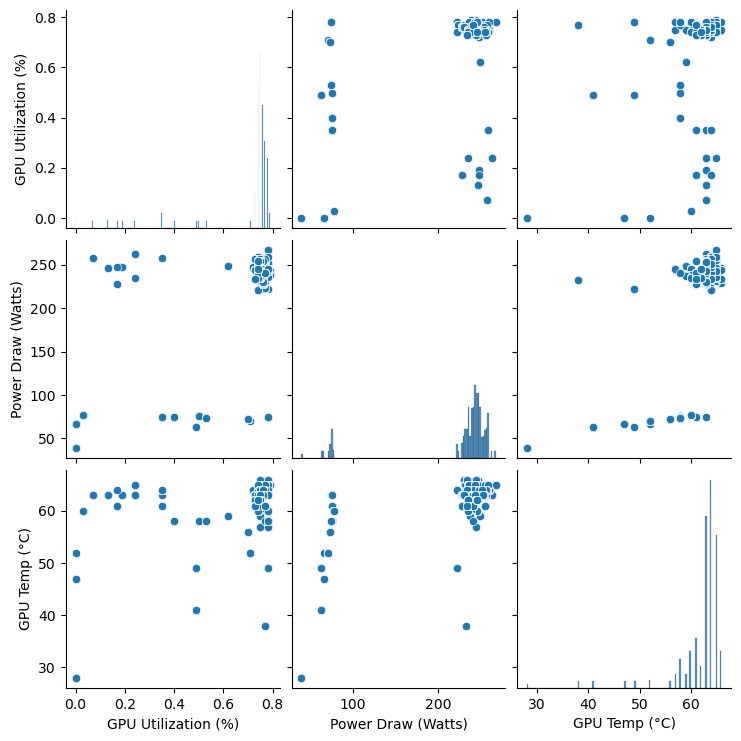

In [28]:
pair_plot = sns.pairplot(live_copy.iloc[:, :3])

In [29]:
column_names = live.columns.tolist()
live_avg = dict(zip(column_names, [list(range(408))] * len(column_names)))
live_avg = pd.DataFrame(live_avg, dtype=np.float64)

In [30]:
temp_df = dict()
count = 0
for iter in range(1, len(reset_iters)):
    # print(f"Count: {str(count)}")
    start_index = reset_iters[iter-1]
    end_index = reset_iters[iter]-1
    # print(f"Current Slice: {str(start_index)}:{str(end_index)}")
    for col in range(len(column_names)):
        temp_list = live.iloc[start_index:end_index,  col].tolist()
        # print(f"On column: {str(col)} with the average: {str(np.average(temp_list))}")
        live_avg.iloc[count, col] = np.float64(np.average(temp_list))
    count+=1

In [31]:
live_avg = live_avg.iloc[:-1,:]

In [32]:
live_avg

,GPU Utilization (%),Power Draw (Watts),GPU Temp (°C),GPU Current Clock (MHz),Memory Allocation Used (MB),Memory Utilization (%),Current Time,Time Delta,Iteration,GPU Clock Utilization,Memory Clock Utilization
0,0.000,39.090000,28.000000,1.080000e+09,4.902093e+08,0.028571,-2.208942e+18,4.928571,7.5,0.765957,1.0
1,0.770,232.600000,38.000000,1.410000e+09,6.808404e+09,0.400000,-2.208942e+18,12.000000,5.5,1.000000,1.0
2,0.770,232.600000,38.000000,1.410000e+09,6.808404e+09,0.390000,-2.208942e+18,19.533333,8.0,1.000000,1.0
3,0.490,62.740000,41.000000,1.410000e+09,6.808404e+09,0.250000,-2.208942e+18,24.666667,2.0,1.000000,1.0
4,0.490,62.740000,41.000000,1.410000e+09,6.808404e+09,0.250000,-2.208942e+18,27.400000,3.0,1.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...
402,0.530,73.790000,58.000000,1.410000e+09,6.810501e+09,0.260000,-2.208941e+18,1595.500000,4.5,1.000000,1.0
403,0.695,208.304286,61.142857,1.397143e+09,6.810501e+09,0.371429,-2.208941e+18,1601.642857,7.5,0.990881,1.0
404,0.740,244.990000,62.000000,1.395000e+09,6.810501e+09,0.390000,-2.208941e+18,1606.000000,1.5,0.989362,1.0
405,0.740,244.990000,62.000000,1.395000e+09,6.810501e+09,0.390000,-2.208941e+18,1607.666667,2.0,0.989362,1.0


In [33]:
from sklearn.preprocessing import normalize, StandardScaler

live_avg_norm = normalize(live_avg)
ss = StandardScaler()
live_avg_scaled = ss.fit_transform(live_avg)

In [34]:
live_avg_scaled = pd.DataFrame(data=live_avg_scaled)
live_avg_scaled.columns = live_avg.columns


live_avg_norm = pd.DataFrame(data=live_avg_norm)
# live_avg_norm['Response Time'] = live_avg.iloc[: , -2:-1]
live_avg_norm.columns = live_avg_norm.columns

In [35]:
live_avg['Resonse Time'] = response_time
live_avg['Eval Rate'] = eval_rates[:-1]

In [36]:
live_avg.to_csv("../data/samples/mega_processed/live_avg.csv")
live_avg_scaled.to_csv("../data/samples/mega_processed/live_avg_scaled.csv")
live_avg_norm.to_csv("../data/samples/mega_processed/live_avg_norm.csv")